In [1]:
import os
os.environ["PYTENSOR_FLAGS"] = "device=cpu,force_linker=py,cxx="

In [2]:
import configparser
from pathlib import Path

BASE_DIR = Path.cwd().parent.parent

def load_config(filename=BASE_DIR / "data/datasets/london_rentals_hierarchical.ini"):
    """Parses the config.ini file into a usable dictionary."""
    # Use inline_comment_prefixes to ignore everything after '#'
    config_parser = configparser.ConfigParser(inline_comment_prefixes=('#',))
    config_parser.read(filename)

    c = {}

    # PRICE ARGUMENTS Section
    price = config_parser['PRICE_ARGUMENTS']
    c['noise_scale'] = float(price['noise_scale'])

    # ANALYSIS Section
    da = config_parser['ANALYSIS']
    c['market_prior_scale'] = float(da['market_prior_scale'])

    return c

config = load_config()

/usr/local/python/3.12.1/lib/python3.12/site-packages/pytensor/configparser.py:316: UserWarning: PyTensor does not recognise this flag: force_linker
  warnings.warn(f"PyTensor does not recognise this flag: {key}")


Hierarchical Dataset Loaded: 1000 properties.
Reference Market Intercept: 7.5
Reference Agent Premium:   0.1


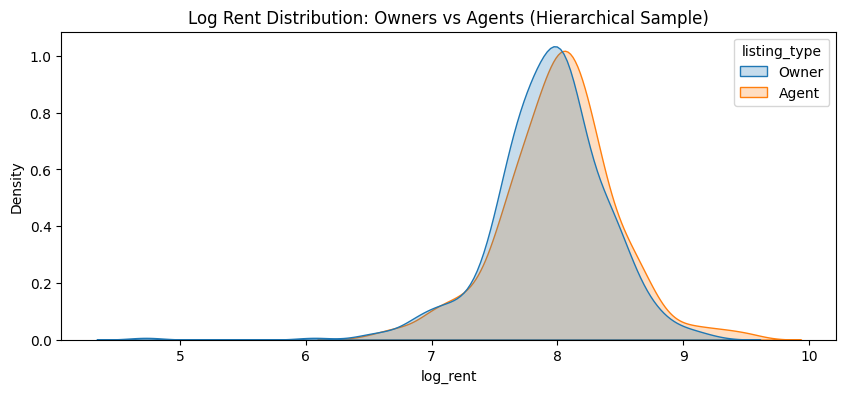

,listing_type,monthly_rent_gbp,log_rent,is_agent
0,Owner,3191.970492,8.068394,0
1,Owner,2045.396359,7.623347,0
2,Owner,4859.008440,8.488590,0
3,Owner,4538.383414,8.420326,0
4,Owner,2297.263533,7.739474,0


In [3]:
import json
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# --- LOAD HIERARCHICAL DATASET ---
# We load the JSON to access the 'metadata' (the true market hyper-parameters)
filename = "../../data/datasets/london_rentals_hierarchical.json"

with open(filename, 'r') as f:
    raw_data = json.load(f)

# Convert properties back to a DataFrame
df = pd.DataFrame(raw_data['properties'])
# Extract the truths for Case B (Agents) as our reference for recovery
market_truth = raw_data['metadata']['agent_market_truth']

# --- FEATURE ENGINEERING & INDEXING ---
df['log_rent'] = np.log(df['monthly_rent_gbp'])

# Categorical mapping for the likelihood function
df['is_house'] = df['property_type'].map({'House': 1, 'Flat': 0})
df['has_garden'] = (df['outdoor_space'] == 'Garden').astype(int)
df['has_terrace'] = (df['outdoor_space'] == 'Terrace').astype(int)
df['has_balcony'] = (df['outdoor_space'] == 'Balcony').astype(int)

# Create an 'is_agent' indicator (0 for Owner, 1 for Agent)
# This allows the model to 'turn on' the premium for the Agent group
df['is_agent'] = (df['listing_type'] == 'Agent').astype(int)

print(f"Hierarchical Dataset Loaded: {len(df)} properties.")
print(f"Reference Market Intercept: {market_truth['means']['intercept']}")
print(f"Reference Agent Premium:   {market_truth['means']['premium']}")

# Visual check of the log_rent distribution across groups
plt.figure(figsize=(10, 4))
sns.kdeplot(data=df, x='log_rent', hue='listing_type', fill=True, common_norm=False)
plt.title("Log Rent Distribution: Owners vs Agents (Hierarchical Sample)")
plt.show()

df[['listing_type', 'monthly_rent_gbp', 'log_rent', 'is_agent']].head()

In [4]:
# SELECT THE TEST PROPERTY
idx = 505
test_prop = df.iloc[idx]
y_obs = test_prop['log_rent']

print(f"Testing Property ID: {test_prop.get('id', idx)}")
print(f"Observed Log Price: {y_obs:.4f}")
print(f"True Listing Type: {test_prop['listing_type']}")
print("-" * 30)

def run_model_selection_hierarchical(y, prop_data, market_truth, mc_draws=1000, is_agent_hyp=False):
    """
    Computes Log-Evidence using specific Market Means and Sigmas.
    """
    means = market_truth['means']
    sigmas = market_truth['sigmas']

    with pm.Model() as model:
        # --- PRIORS: Using the Market Means and Sigmas ---
        intercept = pm.Normal("intercept", mu=means['intercept'], sigma=sigmas['intercept'])
        beta_dist = pm.Normal("beta_dist", mu=means['beta_dist'], sigma=sigmas['beta_dist'])

        # Room impact was generated as a Laplace distribution
        beta_room = pm.Laplace("beta_room", mu=means['beta_room'], b=sigmas['beta_room'])

        mu = (
            intercept +
            (prop_data['n_rooms'] * beta_room) +
            (prop_data['dist_centre_km'] * beta_dist)
        )

        # --- STRUCTURAL FEATURES ---
        if prop_data['near_underground'] == 1:
            mu += pm.Normal("beta_under", mu=means['beta_under'], sigma=sigmas['beta_under'])

        if prop_data['property_type'] == 'House':
            mu += pm.Normal("beta_house", mu=means['beta_house'], sigma=sigmas['beta_house'])

        outdoor = prop_data['outdoor_space']
        if outdoor == 'Garden':
            mu += pm.Normal("beta_garden", mu=means['beta_garden'], sigma=sigmas['beta_garden'])
        elif outdoor == 'Terrace':
            mu += pm.Normal("beta_terrace", mu=means['beta_terrace'], sigma=sigmas['beta_terrace'])
        elif outdoor == 'Balcony':
            mu += pm.Normal("beta_balcony", mu=means['beta_balcony'], sigma=sigmas['beta_balcony'])

        # --- AGENT PREMIUM (Case B Logic) ---
        if is_agent_hyp:
            # We recover the alpha (shape) and beta (rate) from our truth sigmas
            # Variance of Gamma = alpha / beta^2
            mu_p = means['premium']
            sig_p = sigmas['premium']
            alpha_p = (mu_p / sig_p)**2
            beta_p = mu_p / (sig_p**2)

            premium = pm.Gamma("premium", alpha=alpha_p, beta=beta_p)
            mu += premium

        # --- LIKELIHOOD ---
        pm.StudentT("obs", nu=5, mu=mu, sigma=config['noise_scale'], observed=y)

        # --- SMC SAMPLING ---
        trace = pm.sample_smc(
            draws=mc_draws,
            chains=4,
            progressbar=True,
            return_inferencedata=True,
        )

        return trace

# EXECUTION
mc_draws = 1000
print("Computing Evidence: OWNER Hypothesis...")
owner_trace = run_model_selection_hierarchical(y_obs, test_prop, market_truth, mc_draws, is_agent_hyp=False)
log_z_owner = owner_trace.sample_stats.log_marginal_likelihood.mean().item()

print("Computing Evidence: AGENT Hypothesis...")
agent_trace = run_model_selection_hierarchical(y_obs, test_prop, market_truth, mc_draws, is_agent_hyp=True)
log_z_agent = agent_trace.sample_stats.log_marginal_likelihood.mean().item()

# ANALYSIS
log_BF = log_z_agent - log_z_owner
BF = np.exp(log_BF)

print("\n--- RESULTS ---")
print(f"Log Z (Owner): {log_z_owner:.4f}")
print(f"Log Z (Agent): {log_z_agent:.4f}")
print(f"Bayes Factor (K): {BF:.4f}")

if BF > 10:
    print("Conclusion: Strong Evidence for AGENT model.")
elif BF < 0.1:
    print("Conclusion: Strong Evidence for OWNER model.")
else:
    print("Conclusion: Ambiguous Evidence (Inconclusive).")

Initializing SMC sampler...


Testing Property ID: 505
Observed Log Price: 7.6459
True Listing Type: Agent
------------------------------
Computing Evidence: OWNER Hypothesis...


Sampling 4 chains sequentially


Output()

/usr/local/python/3.12.1/lib/python3.12/site-packages/arviz/data/base.py:272: UserWarning: More chains (4) than draws (2). Passed array should have shape (chains, draws, *shape)
  warnings.warn(
Initializing SMC sampler...


Computing Evidence: AGENT Hypothesis...


Sampling 4 chains sequentially


Output()


--- RESULTS ---
Log Z (Owner): 0.8710
Log Z (Agent): 1.0467
Bayes Factor (K): 1.1920
Conclusion: Ambiguous Evidence (Inconclusive).


/usr/local/python/3.12.1/lib/python3.12/site-packages/arviz/data/base.py:272: UserWarning: More chains (4) than draws (1). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


In [5]:
def run_hierarchical_model_selection(df_subset, market_truth, mc_draws=1000, is_agent_hyp=False):
    """
    Computes the Marginal Likelihood (Log Z) for a group of properties
    using a Hierarchical Bayesian framework.

    METHODOLOGY:
    1. Hyper-priors: We define distributions for the UNKNOWN market means and sigmas.
    2. Latent Variables: Every property 'i' gets its own set of betas.
    3. Integration: SMC (Sequential Monte Carlo) integrates over the joint space of
       (Market Hyper-parameters X Individual Property Parameters).

    MATH:
    Log_Rent_i ~ StudentT(nu=5, mu_i, sigma)
    mu_i = Intercept_i + (Rooms_i * Beta_Room_i) + ... + [Premium_i if Agent]
    Intercept_i ~ Normal(mu_market_intercept, sigma_market_intercept)
    Beta_Room_i ~ Laplace(mu_market_room, b_market_room)
    """

    # Pre-calculate feature presence to avoid boolean checks inside the loop
    n_props = len(df_subset)
    rooms = df_subset['n_rooms'].values
    dist = df_subset['dist_centre_km'].values
    is_under = df_subset['near_underground'].values
    is_house = (df_subset['property_type'] == 'House').astype(int)
    is_garden = (df_subset['outdoor_space'] == 'Garden').astype(int)
    is_terrace = (df_subset['outdoor_space'] == 'Terrace').astype(int)
    is_balcony = (df_subset['outdoor_space'] == 'Balcony').astype(int)
    y_obs = df_subset['log_rent'].values

    # Pre-calculate the market truth means
    mt_mu_inter = market_truth["means"]["intercept"]
    mt_mu_beta_room = market_truth["means"]["beta_room"]
    mt_mu_beta_dist = market_truth["means"]["beta_dist"]
    mt_mu_beta_under = market_truth["means"]["beta_under"]
    mt_mu_beta_house = market_truth["means"]["beta_house"]
    mt_mu_beta_garden = market_truth["means"]["beta_garden"]
    mt_mu_beta_terrace = market_truth["means"]["beta_terrace"]
    mt_mu_beta_balcony = market_truth["means"]["beta_balcony"]
    mt_mu_premium = market_truth["means"]["premium"]
    # Pre-calculate the market truth sigmas
    mt_sig_inter = market_truth["sigmas"]["intercept"]
    mt_sig_beta_room = market_truth["sigmas"]["beta_room"]
    mt_sig_beta_dist = market_truth["sigmas"]["beta_dist"]
    mt_sig_beta_under = market_truth["sigmas"]["beta_under"]
    mt_sig_beta_house = market_truth["sigmas"]["beta_house"]
    mt_sig_beta_garden = market_truth["sigmas"]["beta_garden"]
    mt_sig_beta_terrace = market_truth["sigmas"]["beta_terrace"]
    mt_sig_beta_balcony = market_truth["sigmas"]["beta_balcony"]
    mt_sig_premium = market_truth["sigmas"]["premium"]

    with pm.Model() as model:
        # --- LEVEL 2: MARKET HYPER-PRIORS (Unknown Market Parameters) ---
        # We don't assume we know the exact means; we use priors around the expected market values.
        # For simplicity, assume that the error in the market truth mean is always equal to k * market truth sigma,
        # where k is a constant, and that the error in the market truth sigma is always equal to k/sqrt(2) * market truth sigma,
        # motivated by relation between the standard errors (SEs) of the mean and standard deviation, respectively.
        k = config['market_prior_scale']

        mu_m_inter = pm.Normal("mu_m_inter", mu=mt_mu_inter, sigma=k*mt_sig_inter)
        mu_m_beta_room  = pm.Normal("mu_m_beta_room", mu=mt_mu_beta_room, sigma=k*mt_sig_beta_room)
        mu_m_beta_dist  = pm.Normal("mu_m_beta_dist", mu=mt_mu_beta_dist, sigma=k*mt_sig_beta_dist)

        # Market Sigmas
        # Intercept Sigma
        s_err_inter = (k / np.sqrt(2)) * mt_sig_inter
        sig_m_inter = pm.TruncatedNormal("sig_m_inter",
                                         mu=mt_sig_inter,
                                         sigma=s_err_inter,
                                         lower=s_err_inter/100,
                                         upper=mt_sig_inter + (mt_sig_inter - s_err_inter/100))
        # Room Sigma
        s_err_room = (k / np.sqrt(2)) * mt_sig_beta_room
        sig_m_beta_room = pm.TruncatedNormal("sig_m_beta_room",
                                             mu=mt_sig_beta_room,
                                             sigma=s_err_room,
                                             lower=s_err_room/100,
                                             upper=mt_sig_beta_room + (mt_sig_beta_room - s_err_room/100))
        # Distance Sigma
        s_err_dist = (k / np.sqrt(2)) * mt_sig_beta_dist
        sig_m_beta_dist = pm.TruncatedNormal("sig_m_beta_dist",
                                             mu=mt_sig_beta_dist,
                                             sigma=s_err_dist,
                                             lower=s_err_dist/100,
                                             upper=mt_sig_beta_dist + (mt_sig_beta_dist - s_err_dist/100))

        # --- LEVEL 1: INDIVIDUAL PROPERTY PARAMETERS (Latent) ---
        # Every property gets its own unique draw from the market distributions
        prop_intercepts = pm.Normal("p_inter", mu=mu_m_inter, sigma=sig_m_inter, shape=n_props)
        prop_rooms      = pm.Laplace("p_room", mu=mu_m_beta_room, b=sig_m_beta_room, shape=n_props)
        prop_dist       = pm.Normal("p_dist", mu=mu_m_beta_dist, sigma=sig_m_beta_dist, shape=n_props)

        # Base Linear Predictor
        mu = prop_intercepts + (rooms * prop_rooms) + (dist * prop_dist)

        # Structural Features (Partial Pooling)
        # We assume these features have relatively stable market effects.
        # This is a TEST! We know that in reality all pricing arguments assume a different value for each property.
        mu += pm.Normal("b_under", mu=mt_mu_beta_under, sigma=mt_sig_beta_under) * is_under
        mu += pm.Normal("b_house", mu=mt_mu_beta_house, sigma=mt_sig_beta_house) * is_house
        mu += pm.Normal("b_garden", mu=mt_mu_beta_garden, sigma=mt_sig_beta_garden) * is_garden
        mu += pm.Normal("b_terrace", mu=mt_mu_beta_terrace, sigma=mt_sig_beta_terrace) * is_terrace
        mu += pm.Normal("b_balcony", mu=mt_mu_beta_balcony, sigma=mt_sig_beta_balcony) * is_balcony

        # --- HYPOTHESIS: AGENT PREMIUM ---
        if is_agent_hyp:
            mu_m_prem = pm.Normal("mu_m_prem", mu=mt_mu_premium, sigma=k*mt_sig_premium)
            s_err_prem = (k / np.sqrt(2)) * mt_sig_premium
            sig_m_prem = pm.TruncatedNormal("sig_m_prem",
                                            mu=mt_sig_premium,
                                            sigma=s_err_prem,
                                            lower=s_err_prem/100,
                                            upper=mt_sig_premium + (mt_sig_premium - s_err_prem/100))

            # Gamma parameters derived from hyper-priors
            alpha_p = (mu_m_prem / sig_m_prem)**2
            beta_p  = mu_m_prem / (sig_m_prem**2)

            p_premium = pm.Gamma("p_premium", alpha=alpha_p, beta=beta_p, shape=n_props)
            mu += p_premium

        # --- LIKELIHOOD ---
        pm.StudentT("obs", nu=5, mu=mu, sigma=config['noise_scale'], observed=y_obs)

        # --- SAMPLING (SMC for Marginal Likelihood) ---
        trace = pm.sample_smc(
            draws=mc_draws,
            chains=4,
            progressbar=True,
            return_inferencedata=True,
        )
        return trace

In [6]:
# --- EXECUTION: PROPERTY BATCH TEST ---
# We take 10 properties that are ACTUALLY Agents (to see if the model detects them)
test_batch = df[df['listing_type'] == 'Agent'].head(10)
mc_draws=1000

print(f"Running Hierarchical Analysis on {len(test_batch)} properties...")

Running Hierarchical Analysis on 10 properties...


In [7]:
# Trace for Owner Hypothesis
res_owner = run_hierarchical_model_selection(test_batch, market_truth, mc_draws=mc_draws, is_agent_hyp=False)

# Emergency save using Pickle
with open("res_owner.pkl", "wb") as f:
    pickle.dump(res_owner, f)

Initializing SMC sampler...
/usr/local/python/3.12.1/lib/python3.12/site-packages/pytensor/tensor/rewriting/elemwise.py:881: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Sampling 4 chains sequentially


Output()

In [8]:
# Trace for Agent Hypothesis
res_agent = run_hierarchical_model_selection(test_batch, market_truth, mc_draws=mc_draws, is_agent_hyp=True)

with open("res_agent.pkl", "wb") as f:
    pickle.dump(res_agent, f)

Initializing SMC sampler...
/usr/local/python/3.12.1/lib/python3.12/site-packages/pytensor/tensor/rewriting/elemwise.py:881: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(
Sampling 4 chains sequentially


Output()

In [9]:
with open("res_owner.pkl", "rb") as f:
    res_owner = pickle.load(f)

with open("res_agent.pkl", "rb") as f:
    res_agent = pickle.load(f)

In [10]:
log_z_per_chain_owner = np.array([chain[~np.isnan(chain)][0] for chain in res_owner.sample_stats.log_marginal_likelihood.values.astype(float)])
log_z_per_chain_agent = np.array([chain[~np.isnan(chain)][0] for chain in res_agent.sample_stats.log_marginal_likelihood.values.astype(float)])

# Bayes Factor Computation
log_BF = log_z_per_chain_agent.mean() - log_z_per_chain_owner.mean()
BF = np.exp(log_BF)

print("\n--- BATCH RESULTS ---")
print(f"Log Z (Owner Model): {log_z_owner:.4f}")
print(f"Log Z (Agent Model): {log_z_agent:.4f}")
print(f"Group Bayes Factor:  {BF:.4e}")

if BF > 100:
    print("Conclusion: Decisive Evidence for the AGENT hierarchy.")
elif BF < 0.01:
    print("Conclusion: Decisive Evidence for the OWNER hierarchy.")
else:
    print("Conclusion: The evidence is mixed (Partial Pooling suggests ambiguity).")


--- BATCH RESULTS ---
Log Z (Owner Model): 0.8710
Log Z (Agent Model): 1.0467
Group Bayes Factor:  1.4955e+01
Conclusion: The evidence is mixed (Partial Pooling suggests ambiguity).


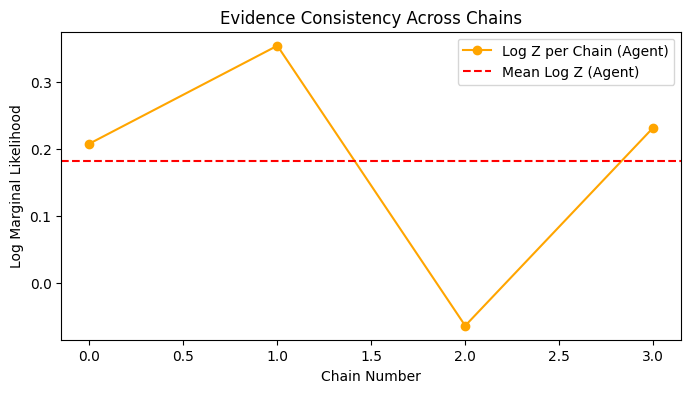

In [11]:
# Check if all 4 chains reached roughly the same conclusion
plt.figure(figsize=(8, 4))
# plt.plot(log_z_per_chain_owner, 'o-', label='Log Z per Chain (Owner)')
# plt.axhline(log_z_per_chain_owner.mean(), color='purple', linestyle='--', label='Mean Log Z (Owner)')
plt.plot(log_z_per_chain_agent, 'o-', color='orange', label='Log Z per Chain (Agent)')
plt.axhline(log_z_per_chain_agent.mean(), color='r', linestyle='--', label='Mean Log Z (Agent)')
plt.xlabel('Chain Number')
plt.ylabel('Log Marginal Likelihood')
plt.title('Evidence Consistency Across Chains')
plt.legend()
plt.show()

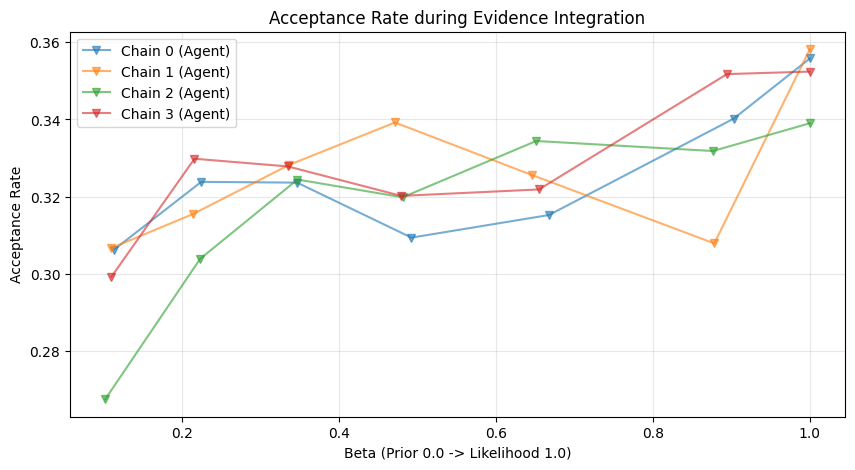

In [12]:
# accept_rates_owner = res_owner.sample_stats["accept_rate"].values
# betas_owner = res_owner.sample_stats["beta"].values
accept_rates_agent = res_agent.sample_stats["accept_rate"].values
betas_agent = res_agent.sample_stats["beta"].values

plt.figure(figsize=(10, 5))

# Plotting the acceptance rate across stages
# for i in range(accept_rates_owner.shape[0]):
#     plt.plot(betas_owner[i], accept_rates_owner[i], 'o-', alpha=0.6, label=f'Chain {i} (Owner)')
for i in range(accept_rates_agent.shape[0]):
    plt.plot(betas_agent[i], accept_rates_agent[i], 'v-', alpha=0.6, label=f'Chain {i} (Agent)')
plt.xlabel('Beta (Prior 0.0 -> Likelihood 1.0)')
plt.ylabel('Acceptance Rate')
plt.title('Acceptance Rate during Evidence Integration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- MARKET HYPER-PARAMETERS (GLOBAL) ---


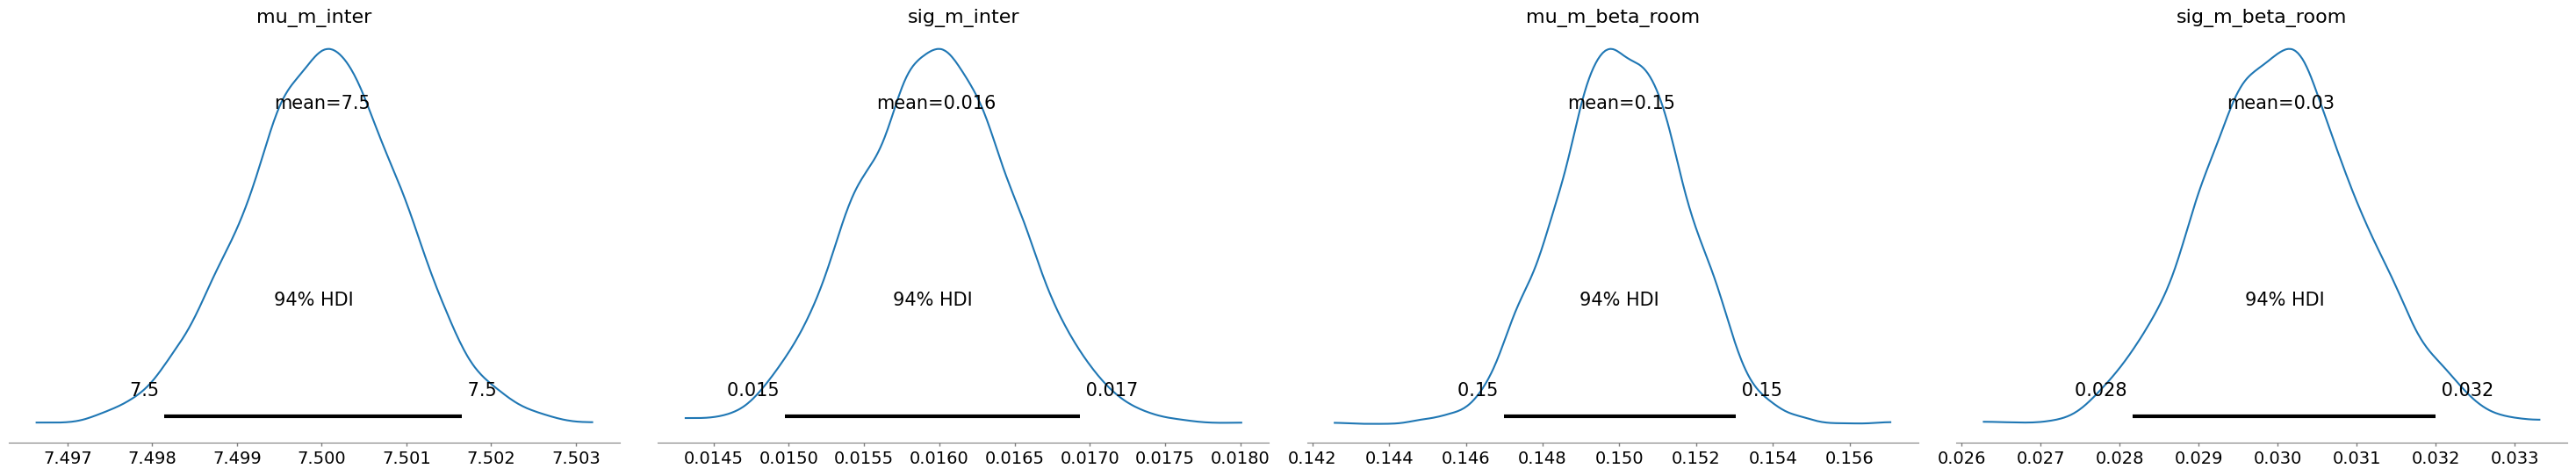

--- STRUCTURAL FEATURES (GLOBAL) ---


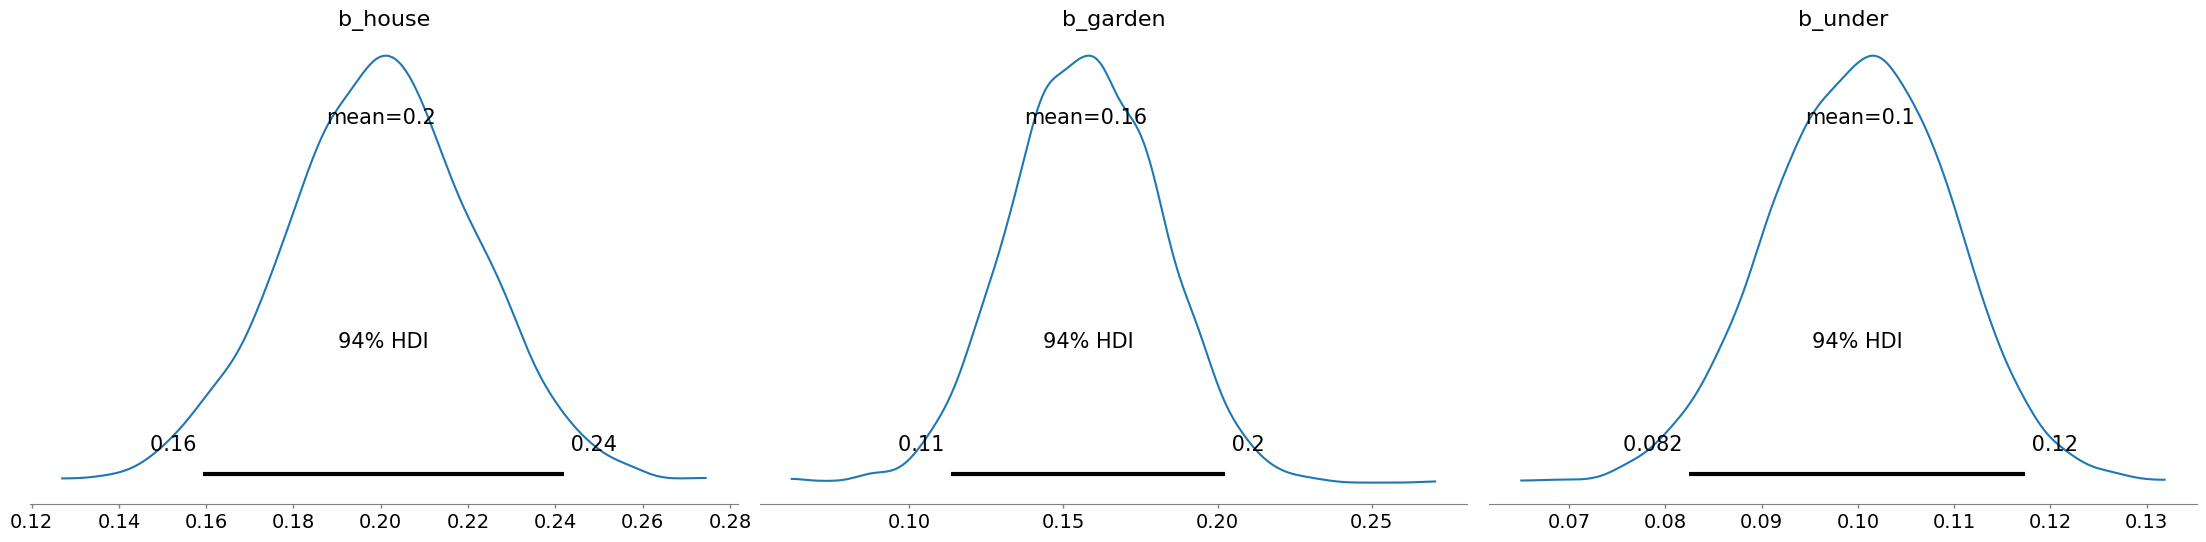

--- INDIVIDUAL PROPERTY RECOVERY (LOCAL - FIRST 3 PROPS) ---


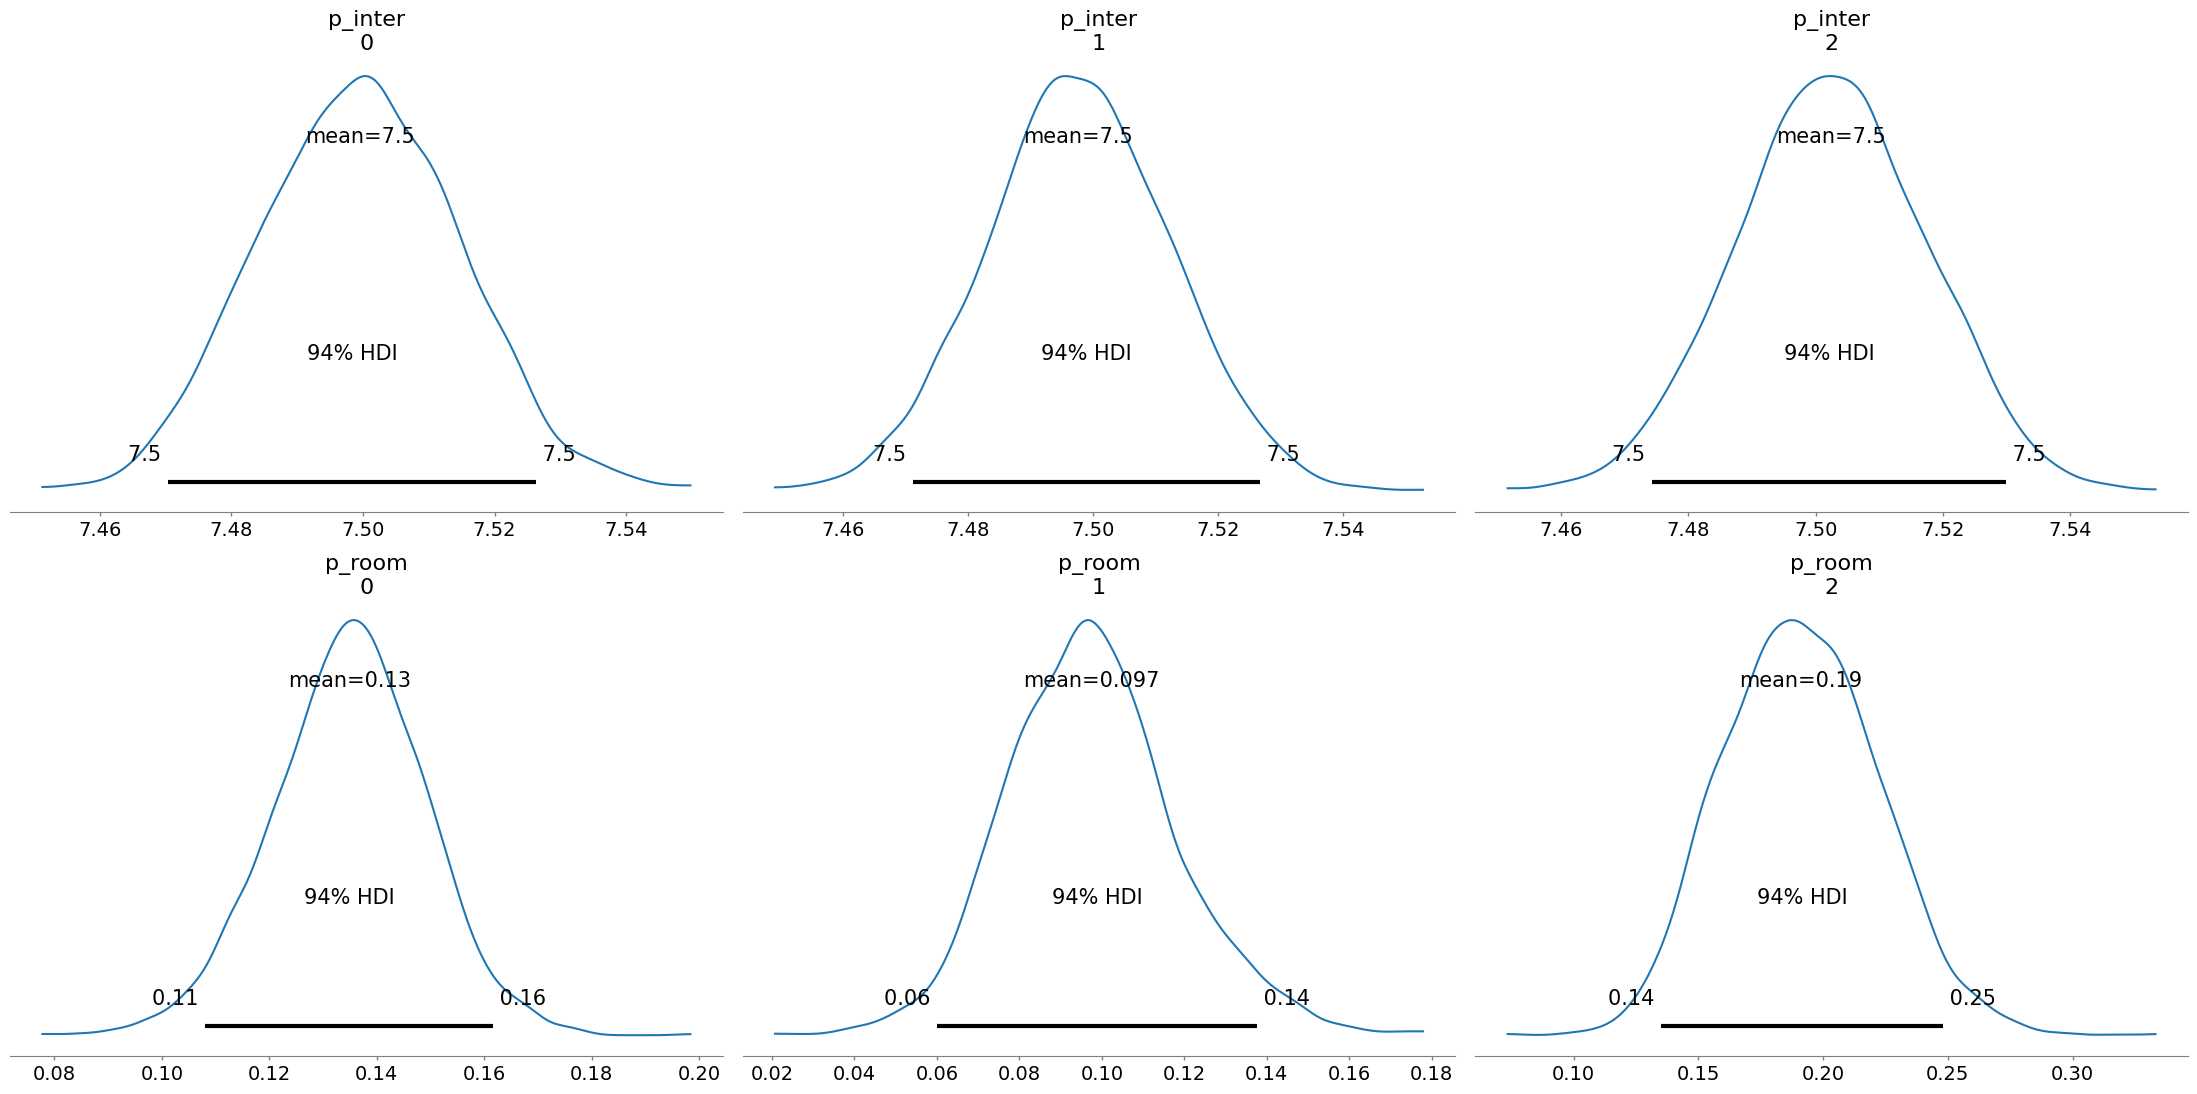

,intercept,beta_room
500,7.503652,0.141295
501,7.516430,0.100122
502,7.486567,0.185009


In [13]:
# ### OWNER
# # Global Market Parameters
# # We look at the market-wide intercept and room effect means.
# print("--- MARKET HYPER-PARAMETERS (GLOBAL) ---")
# az.plot_posterior(res_owner, var_names=['mu_m_inter', 'sig_m_inter', 'mu_m_beta_room', 'sig_m_beta_room'])
# plt.tight_layout()
# plt.show()

# # Structural Features
# # These were estimated as one value for the whole batch (like 'House' recovery)
# print("--- STRUCTURAL FEATURES (GLOBAL) ---")
# az.plot_posterior(res_owner, var_names=['b_house', 'b_garden', 'b_under'])
# plt.tight_layout()
# plt.show()

# # Individual Property Parameters
# # We select the first 3 properties (index 0, 1, 2) to see local variation
# print("--- INDIVIDUAL PROPERTY RECOVERY (LOCAL - FIRST 3 PROPS) ---")
# # We use coords to sub-select from the 'shape=n_props' dimensions
# az.plot_posterior(res_owner,
#                   var_names=['p_inter', 'p_room'],
#                   coords={'p_inter_dim_0': [0, 1, 2], 'p_room_dim_0': [0, 1, 2]})
# plt.tight_layout()
# plt.show()

### AGENT
# Global Market Parameters
# We look at the market-wide intercept and room effect means.
print("--- MARKET HYPER-PARAMETERS (GLOBAL) ---")
az.plot_posterior(res_agent, var_names=['mu_m_inter', 'sig_m_inter', 'mu_m_beta_room', 'sig_m_beta_room'])
plt.tight_layout()
plt.show()

# Structural Features
# These were estimated as one value for the whole batch (like 'House' recovery)
print("--- STRUCTURAL FEATURES (GLOBAL) ---")
az.plot_posterior(res_agent, var_names=['b_house', 'b_garden', 'b_under'])
plt.tight_layout()
plt.show()

# Individual Property Parameters
# We select the first 3 properties (index 0, 1, 2) to see local variation
print("--- INDIVIDUAL PROPERTY RECOVERY (LOCAL - FIRST 3 PROPS) ---")
# We use coords to sub-select from the 'shape=n_props' dimensions
az.plot_posterior(res_agent,
                  var_names=['p_inter', 'p_room'],
                  coords={'p_inter_dim_0': [0, 1, 2], 'p_room_dim_0': [0, 1, 2]})
plt.tight_layout()
plt.show()

test_batch[['intercept', 'beta_room']].head(3)

In [14]:
def perform_hierarchical_ppc(df_subset, market_truth, trace, is_agent_hyp=False):
    # Reconstruct the Data Vectors
    n_props = len(df_subset)
    rooms = df_subset['n_rooms'].values
    dist = df_subset['dist_centre_km'].values
    is_under = df_subset['near_underground'].values
    is_house = (df_subset['property_type'] == 'House').astype(int)
    is_garden = (df_subset['outdoor_space'] == 'Garden').astype(int)
    is_terrace = (df_subset['outdoor_space'] == 'Terrace').astype(int)
    is_balcony = (df_subset['outdoor_space'] == 'Balcony').astype(int)
    y_obs = df_subset['log_rent'].values

    # Re-define the Model Structure
    with pm.Model() as ppc_model:
        k = config['market_prior_scale']

        # Hyper-priors for Global Market Means
        mu_m_inter = pm.Normal("mu_m_inter",
                               mu=market_truth["means"]["intercept"],
                               sigma=k*market_truth["sigmas"]["intercept"])
        mu_m_beta_room = pm.Normal("mu_m_beta_room",
                                   mu=market_truth["means"]["beta_room"],
                                   sigma=k*market_truth["sigmas"]["beta_room"])
        mu_m_beta_dist = pm.Normal("mu_m_beta_dist",
                                   mu=market_truth["means"]["beta_dist"],
                                   sigma=k*market_truth["sigmas"]["beta_dist"])

        # Hyper-priors for Global Market Sigmas
        sig_m_inter = pm.TruncatedNormal("sig_m_inter",
                                         mu=market_truth["sigmas"]["intercept"],
                                         sigma=(k/np.sqrt(2))*market_truth["sigmas"]["intercept"],
                                         lower=(k/np.sqrt(2))*market_truth["sigmas"]["intercept"]/100,
                                         upper=market_truth["sigmas"]["intercept"]+\
            (market_truth["sigmas"]["intercept"]-(k/np.sqrt(2))*market_truth["sigmas"]["intercept"]/100))
        sig_m_beta_room = pm.TruncatedNormal("sig_m_beta_room",
                                             mu=market_truth["sigmas"]["beta_room"],
                                             sigma=(k/np.sqrt(2))*market_truth["sigmas"]["beta_room"],
                                             lower=(k/np.sqrt(2))*market_truth["sigmas"]["beta_room"]/100,
                                             upper=market_truth["sigmas"]["beta_room"]+\
            (market_truth["sigmas"]["beta_room"]-(k/np.sqrt(2))*market_truth["sigmas"]["beta_room"]/100))
        sig_m_beta_dist = pm.TruncatedNormal("sig_m_beta_dist",
                                             mu=market_truth["sigmas"]["beta_dist"],
                                             sigma=(k/np.sqrt(2))*market_truth["sigmas"]["beta_dist"],
                                             lower=(k/np.sqrt(2))*market_truth["sigmas"]["beta_dist"]/100,
                                             upper=market_truth["sigmas"]["beta_dist"]+\
            (market_truth["sigmas"]["beta_dist"]-(k/np.sqrt(2))*market_truth["sigmas"]["beta_dist"]/100))

        # Individual Property Parameters
        p_inter = pm.Normal("p_inter", mu=mu_m_inter, sigma=sig_m_inter, shape=n_props)
        p_room = pm.Laplace("p_room", mu=mu_m_beta_room, b=sig_m_beta_room, shape=n_props)
        p_dist = pm.Normal("p_dist", mu=mu_m_beta_dist, sigma=sig_m_beta_dist, shape=n_props)

        # Linear Predictor
        mu = p_inter + (rooms * p_room) + (dist * p_dist)

        # Structural Features
        mu += pm.Normal("b_under", mu=market_truth["means"]["beta_under"], sigma=market_truth["sigmas"]["beta_under"]) * is_under
        mu += pm.Normal("b_house", mu=market_truth["means"]["beta_house"], sigma=market_truth["sigmas"]["beta_house"]) * is_house
        mu += pm.Normal("b_garden", mu=market_truth["means"]["beta_garden"], sigma=market_truth["sigmas"]["beta_garden"]) * is_garden
        mu += pm.Normal("b_terrace", mu=market_truth["means"]["beta_terrace"], sigma=market_truth["sigmas"]["beta_terrace"]) * is_terrace
        mu += pm.Normal("b_balcony", mu=market_truth["means"]["beta_balcony"], sigma=market_truth["sigmas"]["beta_balcony"]) * is_balcony

        if is_agent_hyp:
            # Reconstruct the Gamma Premium logic
            mu_m_prem = pm.Normal("mu_m_prem",
                                  mu=market_truth["means"]["premium"],
                                  sigma=k*market_truth["sigmas"]["premium"])
            sig_m_prem = pm.TruncatedNormal("sig_m_prem",
                                            mu=market_truth["sigmas"]["premium"],
                                            sigma=(k/np.sqrt(2))*market_truth["sigmas"]["premium"],
                                            lower=(k/np.sqrt(2))*market_truth["sigmas"]["premium"]/100,
                                            upper=market_truth["sigmas"]["premium"]+\
                (market_truth["sigmas"]["premium"]-(k/np.sqrt(2))*market_truth["sigmas"]["premium"]/100))

            alpha_p = (mu_m_prem / sig_m_prem)**2
            beta_p  = mu_m_prem / (sig_m_prem**2)

            p_premium = pm.Gamma("p_premium", alpha=alpha_p, beta=beta_p, shape=n_props)
            mu += p_premium

        # Likelihood
        pm.StudentT("obs", nu=5, mu=mu, sigma=config['noise_scale'], observed=y_obs)

        # Sample Posterior Predictive
        pm.sample_posterior_predictive(trace, extend_inferencedata=True)

    return trace

# --- EXECUTION ---
# Generate predictions for both models using the calculated res_owner and res_agent
print("Generating Hierarchical PPC for Agent Model...")
res_agent_ppc = perform_hierarchical_ppc(test_batch, market_truth, res_agent, is_agent_hyp=True)

# print("Generating Hierarchical PPC for Owner Model...")
# res_owner_ppc = perform_hierarchical_ppc(test_batch, market_truth, res_owner, is_agent_hyp=False)

Sampling: [obs]


Output()

Generating Hierarchical PPC for Agent Model...


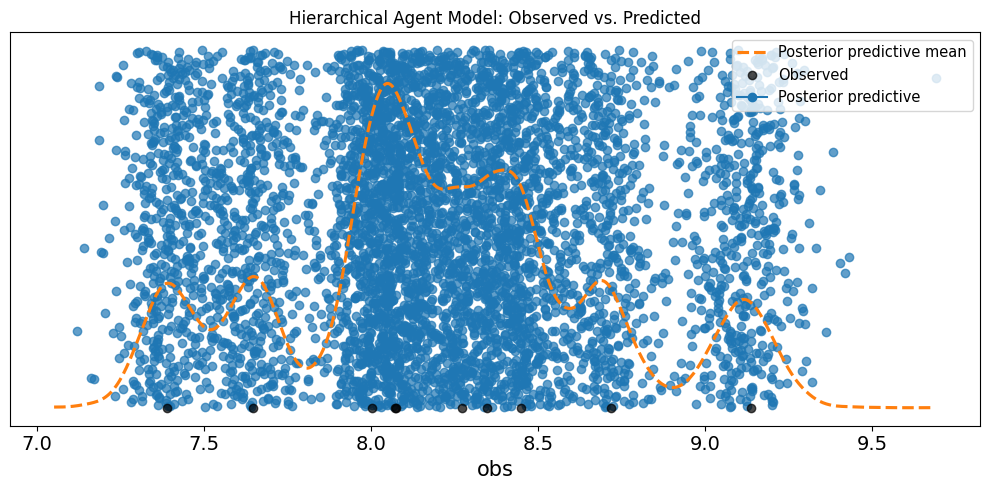

In [15]:
# --- PLOTTING ---
# Hierarchical PPC plot (Agent)
fig1, ax1 = plt.subplots(figsize=(10, 5))
az.plot_ppc(res_agent, kind="scatter", num_pp_samples=500, ax=ax1)
ax1.set_title("Hierarchical Agent Model: Observed vs. Predicted")
plt.tight_layout()
plt.show()

# Hierarchical PPC plot (Owner)
# fig2, ax2 = plt.subplots(figsize=(10, 5))
# az.plot_ppc(res_owner, kind="scatter", num_pp_samples=500, ax=ax2)
# ax2.set_title("Hierarchical Owner Model: Observed vs. Predicted")
# plt.tight_layout()
# plt.show()

In [16]:
# Increase the maximum number of subplots allowed in a grid
az.rcParams["plot.max_subplots"] = 100  # Set this to a high number like 100

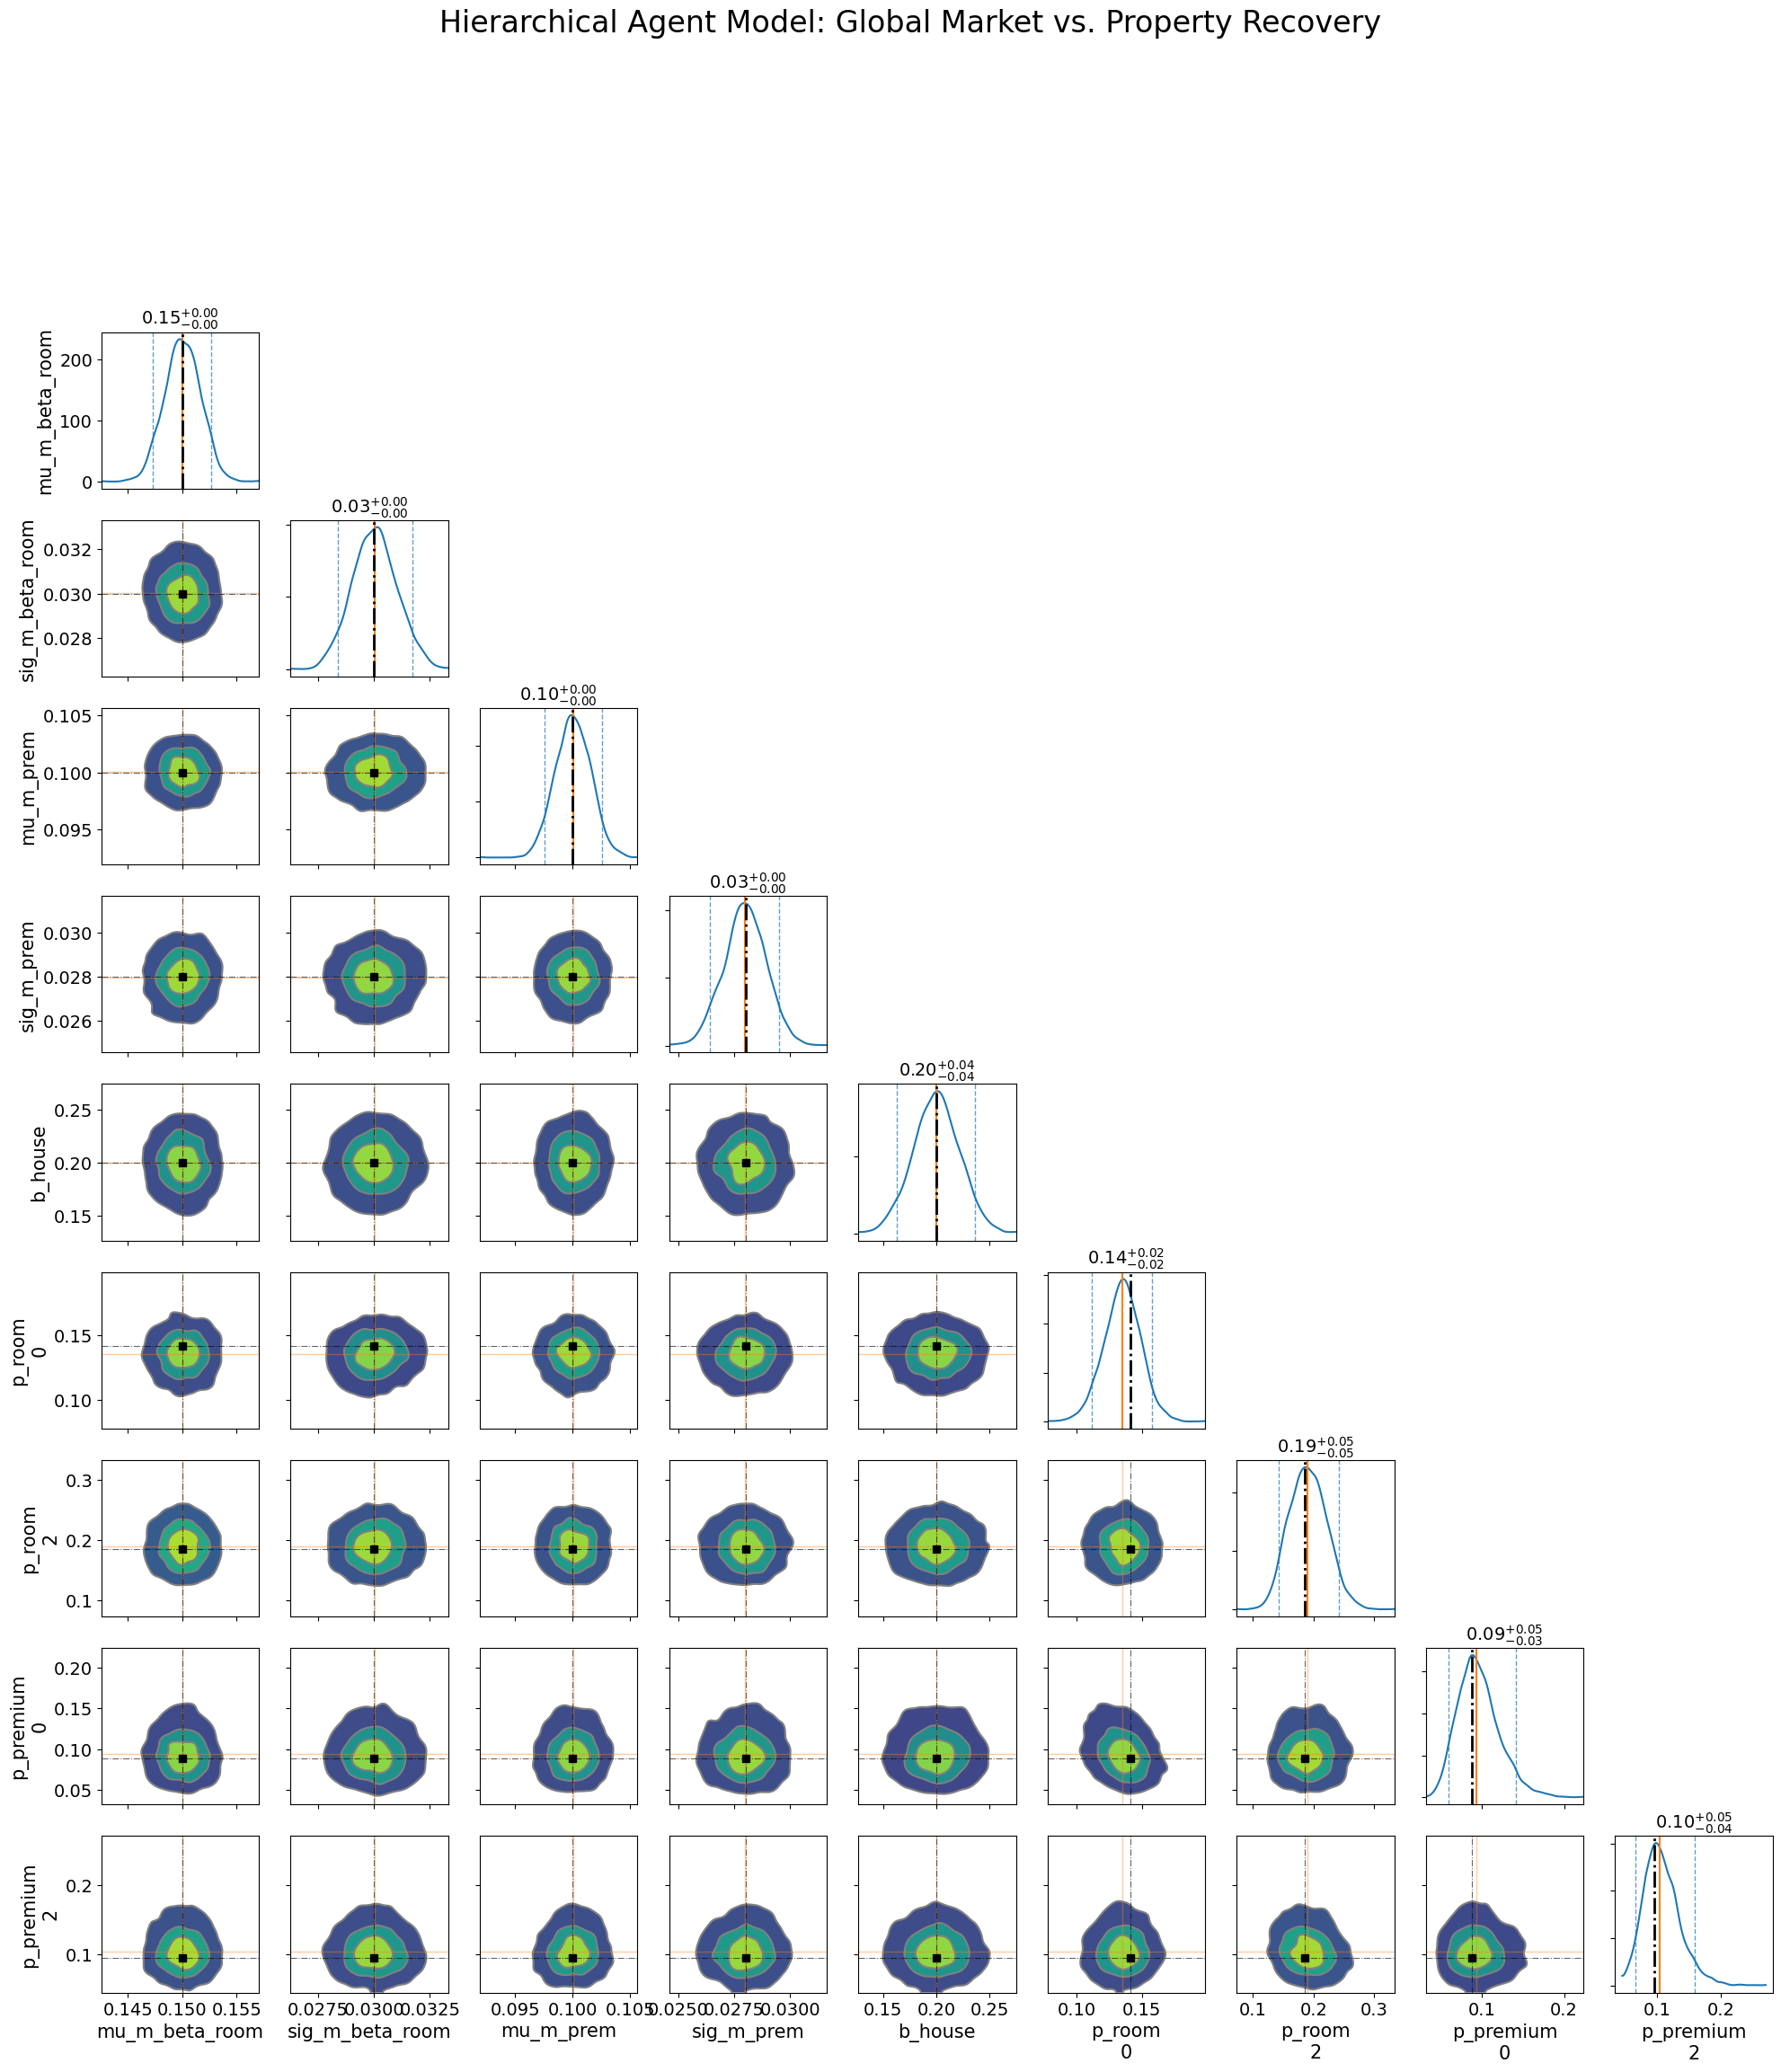

In [17]:
# Define variables and sub-select dimensions for the specific properties
# We'll look at the first and third property in our test_batch
plot_vars = [
    'mu_m_beta_room', 'sig_m_beta_room',
    'mu_m_prem', 'sig_m_prem',
    'b_house', 'p_room', 'p_premium'
]

# Mapping truth values from the market generator and property truth table
hier_truth = {
    "mu_m_beta_room": market_truth['means']['beta_room'],
    "sig_m_beta_room": market_truth['sigmas']['beta_room'],
    "mu_m_prem": market_truth['means']['premium'],
    "sig_m_prem": market_truth['sigmas']['premium'],
    "b_house": market_truth['means']['beta_house'],
    "p_room[0]": test_batch['beta_room'].iloc[0],
    "p_room[2]": test_batch['beta_room'].iloc[2],
    "p_premium[0]": test_batch['premium'].iloc[0],
    "p_premium[2]": test_batch['premium'].iloc[2]
}

# Coordinate selection for ArviZ
coords = {'p_room_dim_0': [0, 2], 'p_premium_dim_0': [0, 2]}

# --- PLOTTING ---
axes = az.plot_pair(
    res_agent,
    var_names=plot_vars,
    coords=coords,
    kind='kde',
    marginals=True,
    figsize=(24, 24),
    kde_kwargs={"hdi_probs": [0.3, 0.6, 0.9]}
)

all_x_labels = [ax.get_xlabel() for ax in axes[-1, :]]
all_y_labels = [ax.get_ylabel() for ax in axes[:, 0]]

for i in range(len(all_y_labels)):
    for j in range(len(all_x_labels)):
        ax = axes[i, j]
        if ax is None: continue

        # Clean labels for mapping
        row_label = all_y_labels[i].replace('\n', '[').strip() + (']' if '\n' in all_y_labels[i] else '')
        col_label = all_x_labels[j].replace('\n', '[').strip() + (']' if '\n' in all_x_labels[j] else '')

        # Extract Posterior Data for Stats
        # We find the original variable name and the index (if any)
        def get_data(label):
            base_var = label.split('[')[0]
            if '[' in label:
                idx = int(label.split('[')[1].split(']')[0])
                # Access specific dimension (e.g., p_room_dim_0)
                dim_name = [d for d in res_agent.posterior[base_var].dims if 'dim' in d][0]
                return res_agent.posterior[base_var].sel({dim_name: idx}).values.flatten()
            return res_agent.posterior[base_var].values.flatten()

        data_col = get_data(col_label)
        q5_c, med_c, q95_c = np.percentile(data_col, [5, 50, 95])

        if i == j:
            # --- 1D STATS (Orange Median + Blue Quantiles) ---
            ax.axvline(q5_c, color='C0', linestyle='--', linewidth=1, alpha=0.7)
            ax.axvline(q95_c, color='C0', linestyle='--', linewidth=1, alpha=0.7)
            ax.axvline(med_c, color='C1', linestyle='-', linewidth=1.5)

            # Add Truth Line (Black Dash-Dot)
            if col_label in hier_truth:
                ax.axvline(hier_truth[col_label], color='black', linestyle='-.', linewidth=2)

            # Set Title with Median and Error
            upper, lower = q95_c - med_c, med_c - q5_c
            ax.set_title(f"${med_c:.2f}^{{+{upper:.2f}}}_{{-{lower:.2f}}}$", fontsize=14)

        elif i > j:
            # --- 2D STATS (Orange Median Crosshair + Black Truth Square) ---
            data_row = get_data(row_label)
            med_r = np.median(data_row)

            # Orange Median lines
            ax.axvline(med_c, color='C1', linestyle='-', linewidth=1, alpha=0.4)
            ax.axhline(med_r, color='C1', linestyle='-', linewidth=1, alpha=0.4)

            # --- TRUTH CROSSHAIRS ---
            if row_label in hier_truth and col_label in hier_truth:
                # Vertical truth line
                ax.axvline(hier_truth[col_label], color='black', linestyle='-.', linewidth=0.8, alpha=0.6)
                # Horizontal truth line
                ax.axhline(hier_truth[row_label], color='black', linestyle='-.', linewidth=0.8, alpha=0.6)
                # Truth Square
                ax.plot(hier_truth[col_label], hier_truth[row_label],
                        marker='s', color='black', markersize=6, zorder=15)

plt.suptitle("Hierarchical Agent Model: Global Market vs. Property Recovery", fontsize=24, y=1.03)
plt.show()

In [18]:
print("AGENT MODEL SUMMARY (Plot Variables Only)")
print("-" * 40)

# We use the same plot_vars and coords defined for the corner plot
stats = az.summary(
    res_agent,
    var_names=plot_vars,
    coords=coords,
    round_to=3
)

print(stats)

AGENT MODEL SUMMARY (Plot Variables Only)
----------------------------------------
                  mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_m_beta_room   0.150  0.002   0.147    0.153      0.000      0.0  3850.159   
sig_m_beta_room  0.030  0.001   0.028    0.032      0.000      0.0  3907.187   
mu_m_prem        0.100  0.002   0.097    0.103      0.000      0.0  3791.314   
sig_m_prem       0.028  0.001   0.026    0.030      0.000      0.0  4074.076   
b_house          0.200  0.022   0.159    0.242      0.000      0.0  2941.511   
p_room[0]        0.135  0.014   0.108    0.162      0.000      0.0  3887.374   
p_room[2]        0.191  0.031   0.135    0.248      0.001      0.0  3870.053   
p_premium[0]     0.096  0.025   0.051    0.143      0.000      0.0  3771.552   
p_premium[2]     0.107  0.028   0.055    0.159      0.000      0.0  3967.482   

                 ess_tail  r_hat  
mu_m_beta_room   3834.106  1.001  
sig_m_beta_room  3735.198  1.000  
mu_m_prem  

In [19]:
hier_results = []

# Define the parameters and their specific indices (for vectorized vars)
# base_name: (truth_key, dimension_index or None)
hier_vars_map = {
    "mu_m_beta_room": ("mu_m_beta_room", None),
    "sig_m_beta_room": ("sig_m_beta_room", None),
    "mu_m_prem": ("mu_m_prem", None),
    "sig_m_prem": ("sig_m_prem", None),
    "b_house": ("b_house", None),
    "p_room_0": ("p_room[0]", 0),
    "p_room_2": ("p_room[2]", 2),
    "p_premium_0": ("p_premium[0]", 0),
    "p_premium_2": ("p_premium[2]", 2),
}

# Compute Z-Scores
for display_name, (truth_key, idx) in hier_vars_map.items():
    base_var = display_name.rsplit('_', 1)[0] if idx is not None else display_name

    # Extract samples
    if idx is None:
        # Scalar parameter
        post_samples = res_agent.posterior[base_var].values.flatten()
    else:
        # Vector parameter - find the correct dimension name (e.g., p_room_dim_0)
        dim_name = [d for d in res_agent.posterior[base_var].dims if 'dim' in d][0]
        post_samples = res_agent.posterior[base_var].sel({dim_name: idx}).values.flatten()

    post_median = np.median(post_samples)
    post_sd = np.std(post_samples)
    injected_truth = hier_truth[truth_key]

    z_score = (post_median - injected_truth) / post_sd

    hier_results.append({
        "Model": "Hierarchical Agent",
        "Parameter": truth_key,
        "Injected Truth": injected_truth,
        "Posterior Median": post_median,
        "Posterior SD": post_sd,
        "Z-Score": z_score
    })

# Display Results
from matplotlib.colors import LinearSegmentedColormap

# Create a symmetric map: Red (-3) -> Green (0) -> Red (+3)
cmap_symmetric = LinearSegmentedColormap.from_list("Z_map", ["#d73027", "#1a9850", "#d73027"])

z_score_hier_df = pd.DataFrame(hier_results)

print("Hierarchical Recovery Analysis: Market Stats & Property-Specific 'Wobbles'")
display(z_score_hier_df.style.format({
    "Injected Truth": "{:.3f}",
    "Posterior Median": "{:.3f}",
    "Posterior SD": "{:.3f}",
    "Z-Score": "{:.2f}"
}).background_gradient(subset=['Z-Score'], cmap=cmap_symmetric, vmin=-3, vmax=3))

print("\nHierarchical Interpretation Guide:")
print(f"{'-'*30}")
print("- |Z| < 1.0: Strong Recovery.")
print("- 1.0 < |Z| < 2.0: Normal Hierarchical Tension.")
print("- |Z| > 2.0: Significant Shrinkage or Outlier.")

Hierarchical Recovery Analysis: Market Stats & Property-Specific 'Wobbles'


,Model,Parameter,Injected Truth,Posterior Median,Posterior SD,Z-Score
0,Hierarchical Agent,mu_m_beta_room,0.150,0.150,0.002,0.03
1,Hierarchical Agent,sig_m_beta_room,0.030,0.030,0.001,0.03
2,Hierarchical Agent,mu_m_prem,0.100,0.100,0.002,0.02
3,Hierarchical Agent,sig_m_prem,0.028,0.028,0.001,-0.02
4,Hierarchical Agent,b_house,0.200,0.200,0.022,0.00
5,Hierarchical Agent,p_room[0],0.141,0.135,0.014,-0.43
6,Hierarchical Agent,p_room[2],0.185,0.190,0.031,0.17
7,Hierarchical Agent,p_premium[0],0.089,0.094,0.025,0.20
8,Hierarchical Agent,p_premium[2],0.095,0.104,0.028,0.32



Hierarchical Interpretation Guide:
------------------------------
- |Z| < 1.0: Strong Recovery.
- 1.0 < |Z| < 2.0: Normal Hierarchical Tension.
- |Z| > 2.0: Significant Shrinkage or Outlier.


In [20]:
# --- DEFINE P-VALUE FUNCTION ---
def compute_two_tailed_p_val(samples, truth):
    """
    Calculates the two-tailed Bayesian p-value.
    Defined as 2 * min(Pr(theta > truth), Pr(theta < truth)).
    """
    prob_greater = np.mean(samples > truth)
    prob_less = np.mean(samples < truth)
    return 2 * min(prob_greater, prob_less)

# --- PREPARE HIERARCHICAL DATASET ---
two_tailed_hier_results = []

# --- COMPUTE P-VALUES ---
for display_name, (truth_key, idx) in hier_vars_map.items():
    # Identify the base variable name (e.g., 'p_room')
    base_var = display_name.rsplit('_', 1)[0] if idx is not None else display_name

    # Extract posterior samples
    if idx is None:
        post_samples = res_agent.posterior[base_var].values.flatten()
    else:
        # Dynamically find the coordinate dimension name
        dim_name = [d for d in res_agent.posterior[base_var].dims if 'dim' in d][0]
        post_samples = res_agent.posterior[base_var].sel({dim_name: idx}).values.flatten()

    injected_truth = hier_truth[truth_key]
    p_val = compute_two_tailed_p_val(post_samples, injected_truth)

    two_tailed_hier_results.append({
        "Model": "Hierarchical Agent",
        "Parameter": truth_key,
        "Injected Truth": injected_truth,
        "Posterior Median": np.median(post_samples),
        "Two-Tailed p-value": p_val,
        "Recovery Status": "Success" if p_val >= 0.05 else "Shrinkage Warning"
    })

# --- DISPLAY RESULTS ---
two_tailed_hier_df = pd.DataFrame(two_tailed_hier_results)
print("Hierarchical Two-Tailed Recovery Analysis")
display(two_tailed_hier_df.style.format({
    "Injected Truth": "{:.3f}",
    "Posterior Median": "{:.3f}",
    "Two-Tailed p-value": "{:.3f}"
}).background_gradient(subset=['Two-Tailed p-value'], cmap='RdYlGn', vmin=0, vmax=1))

print("\nHierarchical Deep-Dive:")
print("- p-value > 0.05: Truth is statistically plausible.")
print("- p-value < 0.05: Truth is an outlier relative to the posterior (Likely due to heavy Shrinkage).")

Hierarchical Two-Tailed Recovery Analysis


,Model,Parameter,Injected Truth,Posterior Median,Two-Tailed p-value,Recovery Status
0,Hierarchical Agent,mu_m_beta_room,0.150,0.150,0.983,Success
1,Hierarchical Agent,sig_m_beta_room,0.030,0.030,0.980,Success
2,Hierarchical Agent,mu_m_prem,0.100,0.100,0.981,Success
3,Hierarchical Agent,sig_m_prem,0.028,0.028,0.983,Success
4,Hierarchical Agent,b_house,0.200,0.200,1.000,Success
5,Hierarchical Agent,p_room[0],0.141,0.135,0.646,Success
6,Hierarchical Agent,p_room[2],0.185,0.190,0.865,Success
7,Hierarchical Agent,p_premium[0],0.089,0.094,0.833,Success
8,Hierarchical Agent,p_premium[2],0.095,0.104,0.725,Success



Hierarchical Deep-Dive:
- p-value > 0.05: Truth is statistically plausible.
- p-value < 0.05: Truth is an outlier relative to the posterior (Likely due to heavy Shrinkage).


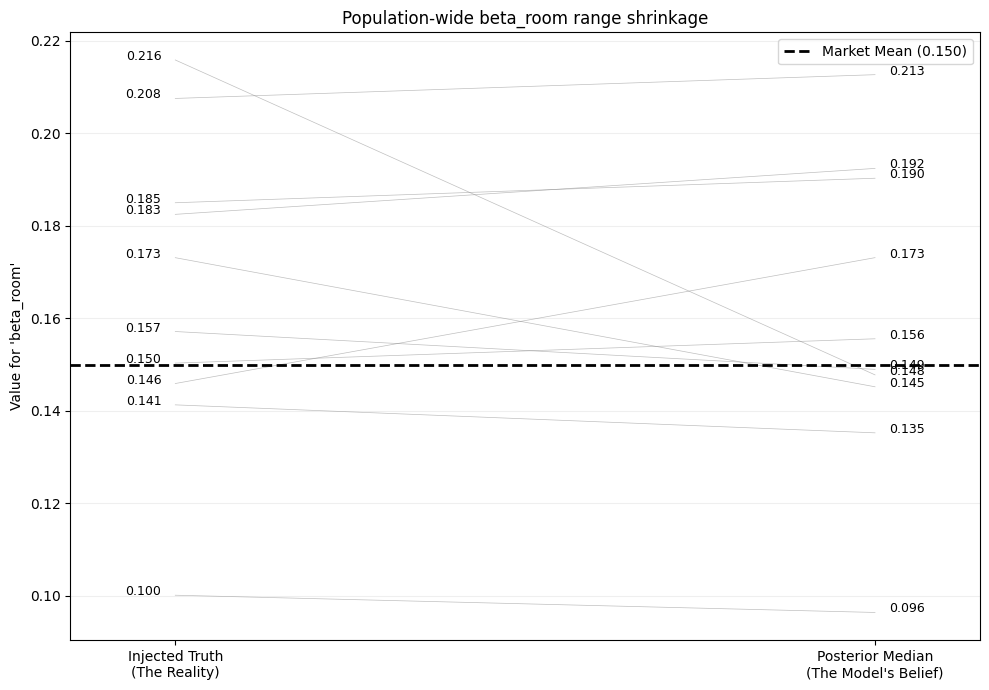

In [21]:
# Extract the ground truth for all properties in test_batch
hier_truth_list_room = test_batch['beta_room'].values

# Extract global market mean
market_mean = hier_truth["mu_m_beta_room"]

# Get the posterior medians from the hierarchical model
p_room_post = res_agent.posterior["p_room"].median(dim=["chain", "draw"]).values

plt.figure(figsize=(10, 7))

# Iterate through all test_batch properties
for i in range(len(hier_truth_list_room)):
    truth_val = hier_truth_list_room[i]
    recovered_val = p_room_post[i]

    plt.plot([0, 1], [truth_val, recovered_val], color='grey', alpha=0.5, linewidth=0.5)

    plt.text(-0.02, truth_val, f"{truth_val:.3f}", ha='right', fontsize=9)
    plt.text(1.02, recovered_val, f"{recovered_val:.3f}", ha='left', fontsize=9)

# Add the Market Mean
plt.axhline(market_mean, color='black', linestyle='--', linewidth=2, label=f"Market Mean ({market_mean:.3f})")

# Formatting the shrinkage
plt.xticks([0, 1], ["Injected Truth\n(The Reality)", "Posterior Median\n(The Model's Belief)"])
plt.ylabel("Value for 'beta_room'")
plt.title("Population-wide beta_room range shrinkage")
plt.grid(axis='y', alpha=0.2)
plt.legend(loc='upper right', bbox_to_anchor=(1, 1))

# Expand limits slightly for text labels
plt.xlim(-0.15, 1.15)
plt.tight_layout()

plt.show()